# Causal Uplift Modeling with Double ML IV
## Criteo Incrementality Dataset

**Business Question:**
Does ad exposure causally increase user visits and conversions and which users respond most?

**Why this is interesting:**
Naive comparison of exposed vs unexposed users is biased. Users who see ads are 
systematically different from those who dont (selection bias). Additionally, actual 
ad exposure is endogenous users self select into seeing ads in ways we cant fully 
observe. Standard regression fails on both counts.

**Methodology:**
We use Double ML with an Instrumental Variable (DMLIV) to estimate causal effects. 
Treatment assignment (randomly determined by Criteo) serves as the instrument for 
actual ad exposure. We then estimate Conditional Average Treatment Effects (CATE) 
to identify which user segments respond most, and translate findings into a 
targeting policy.

**Stack:** Python · EconML · LightGBM · scikit-learn · pandas · matplotlib

---

**Data:** Criteo Uplift Modeling Dataset  
**Source:** https://ailab.criteo.com/criteo-uplift-prediction-dataset/  
**Description:** 14M rows from randomized incrementality tests. Each row is a user 
with 12 anonymized features, a treatment indicator, and two outcome labels.  
**Privacy note:** Criteo deliberately scrambled the true incrementality level for 
privacy. This project demonstrates methodology, not Criteo's actual business metrics.

| Column | Role | Description |
|---|---|---|
| f0–f11 | Confounders (X) | Anonymized user features |
| treatment | Instrument (Z) | Randomly assigned targeting (1=targeted) |
| exposure | Treatment (D) | Actually saw the ad (endogenous) |
| visit | Outcome (Y) | User visited the site |
| conversion | Secondary outcome | User converted |

In [ ]:
import pandas as pd

df = pd.read_csv('data/criteo-uplift-v2.1.csv')


---
## Section 2 : Data Loading & Exploratory Data Analysis

Before any modeling, we interrogate the data directly. In causal inference EDA 
is not just familiarization it is assumption checking. Class imbalance, data 
structure, and distribution of outcomes all directly affect which methods are 
valid and how we configure them.

          f0         f1        f2        f3         f4        f5        f6  \
0  12.616365  10.059654  8.976429  4.679882  10.280525  4.115453  0.294443   
1  12.616365  10.059654  9.002689  4.679882  10.280525  4.115453  0.294443   
2  12.616365  10.059654  8.964775  4.679882  10.280525  4.115453  0.294443   
3  12.616365  10.059654  9.002801  4.679882  10.280525  4.115453  0.294443   
4  12.616365  10.059654  9.037999  4.679882  10.280525  4.115453  0.294443   

         f7        f8         f9       f10       f11  treatment  conversion  \
0  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
1  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
2  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
3  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
4  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   

   visit  exposure  
0      0         0  
1      0      

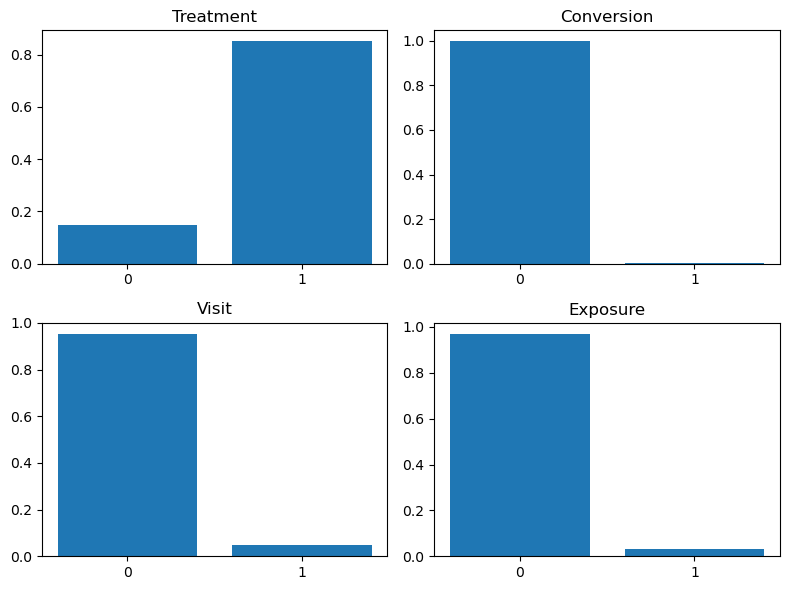

treatment
1    0.85
0    0.15
Name: proportion, dtype: float64
conversion
0    0.997083
1    0.002917
Name: proportion, dtype: float64
visit
0    0.953008
1    0.046992
Name: proportion, dtype: float64
exposure
0    0.969369
1    0.030631
Name: proportion, dtype: float64


In [2]:
import matplotlib.pyplot as plt
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

fig, axes = plt.subplots(2,2, figsize=(8,6))
axes = axes.flatten()

counts = df['treatment'].value_counts(normalize=True).sort_index()
axes[0].bar(counts.index, counts.values)
axes[0].set_title('Treatment')

counts = df['conversion'].value_counts(normalize=True).sort_index()
axes[1].bar(counts.index, counts.values)
axes[1].set_title('Conversion')

counts = df['visit'].value_counts(normalize=True).sort_index()
axes[2].bar(counts.index, counts.values)
axes[2].set_title('Visit')

counts = df['exposure'].value_counts(normalize=True).sort_index()
axes[3].bar(counts.index, counts.values)
axes[3].set_title('Exposure')

axes[0].set_xticks([0, 1])
axes[1].set_xticks([0, 1])
axes[2].set_xticks([0, 1])
axes[3].set_xticks([0, 1])
plt.tight_layout()
plt.show()

print(df['treatment'].value_counts(normalize=True))
print(df['conversion'].value_counts(normalize=True))
print(df['visit'].value_counts(normalize=True))
print(df['exposure'].value_counts(normalize=True))


### Panel Structure Check : Is Difference-in-Differences Applicable?

DiD requires the same units observed across multiple time periods. The dataset 
has no timestamp column, so we check whether repeated user observations exist 
in the feature vectors which would allow us to reconstruct a synthetic panel.


In [ ]:
feature_cols = [f'f{i}' for i in range(12)]
duplicates = df.duplicated(subset=feature_cols, keep=False)
print("Total Duplicates = ", duplicates.sum())
print(f"% of duplicates = {duplicates.mean() * 100:.2f}%")
user_counts = df.groupby(feature_cols).size()
print("Unique users = ", len(user_counts))
print("How many each user repeated = ", user_counts.value_counts().sort_index().head(10))
print("Distribution of users : ",user_counts.describe())

Total Duplicates =  2811714
% of duplicates = 20.112990422038067
Unique users =  12353333
How many each user repeated =  1     11167878
2       883458
3       209059
4        62429
5        20352
6         6706
7         2286
8          753
9          293
10          77
Name: count, dtype: int64
Distribution of users :  count    1.235333e+07
mean     1.131645e+00
std      4.683245e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.300000e+01
dtype: float64


### DiD Rejected : Reasoning

90.4% of users appear exactly once in the dataset. A credible panel requires 
repeated observations of the same units across time. Engineering synthetic time 
periods on top of single observations would be methodologically dishonest we 
would be manufacturing longitudinal structure that does not exist.


---
## Section 3 Causal Assumptions & Pre-Modeling Checks

Every causal method rests on assumptions. We check what is empirically testable 
before building anything if assumptions fail, the model is invalid regardless 
of how clean the code is.

**Assumptions we argue (not testable with data):**

- **SUTVA:** Criteo's experiment operates at the individual user level with no 
  social network component, making interference between units unlikely. Treatment 
  is binary, ruling out multiple treatment versions.
  
- **Consistency:** Treatment is binary exposure to a display ad with consistent 
  format across users. Potential outcomes are well defined under each treatment level.

- **Unconfoundedness of Z:** We do not rely on unconfoundedness of actual exposure D. 
  Instead we use treatment assignment Z as an instrument a much more defensible 
  assumption since Z was randomly assigned by Criteo.

**Assumptions we test empirically:**

- Test 1 : Overlap / Positivity
- Test 2 : OLS vs Double ML (motivation for methodology)
- Instrument strength (F-statistic)
- Instrument exogeneity (nuisance model AUC on Z)

In [4]:
# Data prep sample from the dataset 1M row with the same original proportions to conserve the proportions of the control and treatment groups

import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)
df_sample, _ = train_test_split(df, train_size=1000000, stratify=df['treatment'], random_state=42)
print("Sample shape = ", df_sample.shape)
print("Treatment prop = ", df_sample['treatment'].value_counts(normalize=True))
print("Exposure prop = ", df_sample['exposure'].value_counts(normalize=True))

X = df_sample[feature_cols].values
Z = df_sample['treatment'].values
D = df_sample['exposure'].values
Y = df_sample['visit'].values

print("X shape = ",X.shape)
print("Z shape = ",Z.shape)
print("D shape = ",D.shape)
print("Y shape = ",Y.shape)

print("Visit mean = ",df_sample['visit'].mean())
print("Exposure mean = ",df_sample['exposure'].mean())
print("Treatment mean = ",df_sample['treatment'].mean())

# exposure is 0.03 so a very little number of those flagged for treatment actually got it and this might lower the strength of the first stage as P(D=1|Z=1) = 0.03/0.85 = 3.6%
# checking P(D=1|Z=0)
print(df.groupby('treatment')['exposure'].mean())
# there are no individuals in the control group that got exposed to the treatment so the IV wont be contaiminated now calculating the F-statistic will tell how strong the first stage will be 
delta = 0.036
n = len(df_sample)
var_Z = np.var(df_sample['treatment'], ddof=1)
alpha = D.mean() - delta * Z.mean()
D_hat = alpha + delta * df_sample['treatment']
residuals = df_sample['exposure'] - D_hat
sigma2 = np.sum(residuals**2) / (n - 2)

F = (delta**2 * n * var_Z) / sigma2
print(f"F: {F:.2f}")
# F-stat = 5630 >>> 10 : strong first stage

Sample shape =  (1000000, 16)
Treatment prop =  treatment
1    0.85
0    0.15
Name: proportion, dtype: float64
Exposure prop =  exposure
0    0.96925
1    0.03075
Name: proportion, dtype: float64
X shape =  (1000000, 12)
Z shape =  (1000000,)
D shape =  (1000000,)
Y shape =  (1000000,)
Visit mean =  0.046849
Exposure mean =  0.03075
Treatment mean =  0.85
treatment
0    0.000000
1    0.036037
Name: exposure, dtype: float64
F: 5575.35


### Test 1 : Overlap / Positivity

**Assumption:** Every user must have a nonzero probability of receiving either 
treatment value:

Overall stats:
Min:  0.8184
Max:  0.9461
Mean: 0.8500
Treated group propensity scores:
Mean: 0.8500  Std: 0.0071

Control group propensity scores:
Mean: 0.8497  Std: 0.0064

Common support range: [0.8266, 0.9307]
Users in common support: 999,974 (100.0%)


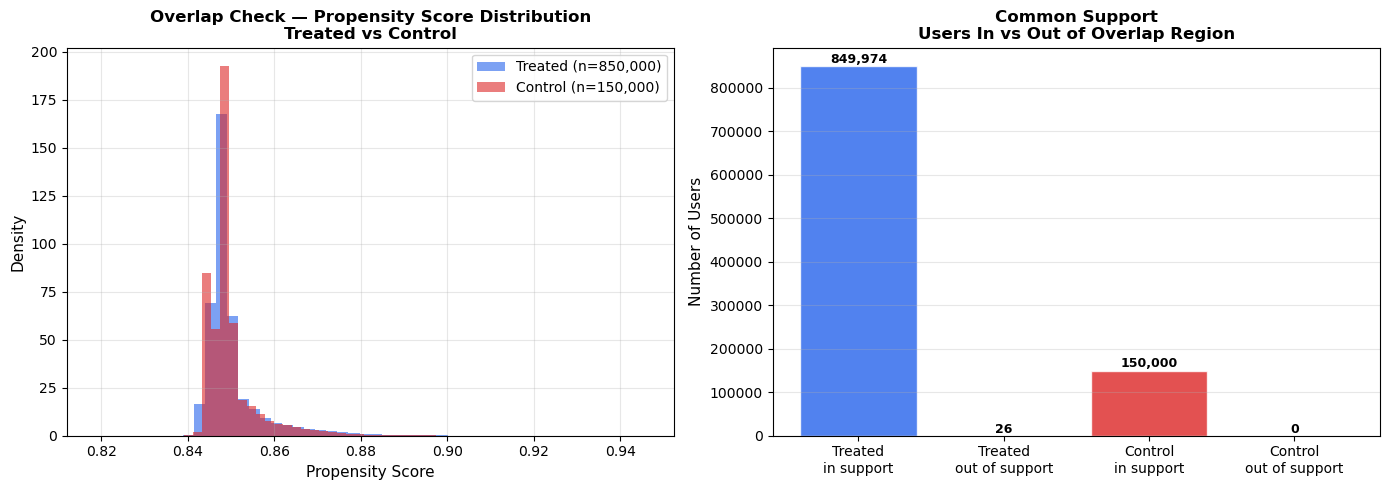

In [ ]:
# checking testable assumptions : overlap / positivity
# all individuals needs to have non zero chance of getting the either treatment (control/treatment) => all in the same support

from sklearn.linear_model import LogisticRegression

propensity_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
propensity_model.fit(X, Z) 
propensity_scores = propensity_model.predict_proba(X)[:, 1]

print("Overall stats:")
print(f"Min:  {propensity_scores.min():.4f}")
print(f"Max:  {propensity_scores.max():.4f}")
print(f"Mean: {propensity_scores.mean():.4f}")

ps_treated = propensity_scores[Z == 1]
ps_control = propensity_scores[Z == 0]
print("Treated group propensity scores:")
print(f"Mean: {ps_treated.mean():.4f}  Std: {ps_treated.std():.4f}")
print("Control group propensity scores:")
print(f"Mean: {ps_control.mean():.4f}  Std: {ps_control.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ps_treated, bins=50, alpha=0.6, color='#2563EB', density=True, label=f'Treated (n={len(ps_treated):,})')
axes[0].hist(ps_control, bins=50, alpha=0.6, color='#DC2626', density=True, label=f'Control (n={len(ps_control):,})')
axes[0].set_xlabel('Propensity Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Overlap Check — Propensity Score Distribution\nTreated vs Control', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


lower_bound = max(ps_treated.min(), ps_control.min())
upper_bound = min(ps_treated.max(), ps_control.max())
in_support = ((propensity_scores >= lower_bound) & (propensity_scores <= upper_bound))
print(f"Common support range: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Users in common support: {in_support.sum():,} ({in_support.mean():.1%})")

support_by_group = {
    'Treated\nin support': ((Z==1) & in_support).sum(),
    'Treated\nout of support': ((Z==1) & ~in_support).sum(),
    'Control\nin support': ((Z==0) & in_support).sum(),
    'Control\nout of support': ((Z==0) & ~in_support).sum()
}
colors = ['#2563EB', '#93C5FD', '#DC2626', '#FCA5A5']
bars = axes[1].bar(support_by_group.keys(), support_by_group.values(),color=colors, alpha=0.8, edgecolor='white')
axes[1].set_ylabel('Number of Users', fontsize=11)
axes[1].set_title('Common Support\nUsers In vs Out of Overlap Region', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, support_by_group.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### Test 2 : Naive OLS vs Double ML

**Why this matters:** OLS estimates the treatment effect assuming (1) linear 
relationships between confounders and outcomes, and (2) no endogeneity in 
treatment assignment. We test both assumptions by comparing four estimators 
of increasing methodological rigor.

The gap between OLS and DMLIV quantifies the total bias a naive analyst would 
introduce and lets us decompose it into confounding bias vs endogeneity bias.

ASSUMPTION TEST 2 — NAIVE OLS vs DOUBLE ML
[1] Naive OLS Treatment Effect:     0.254550
[2] Partially Linear OLS Effect:    0.254550
[3] Double ML Manual Effect:        0.081889
[4] DMLIV (with IV, from earlier):  -0.006229

BIAS ANALYSIS
OLS bias vs DML:          0.172661
Partial OLS bias vs DML:  0.172661
DML bias vs DMLIV:        0.088118

OLS overestimates effect by: 210.8%


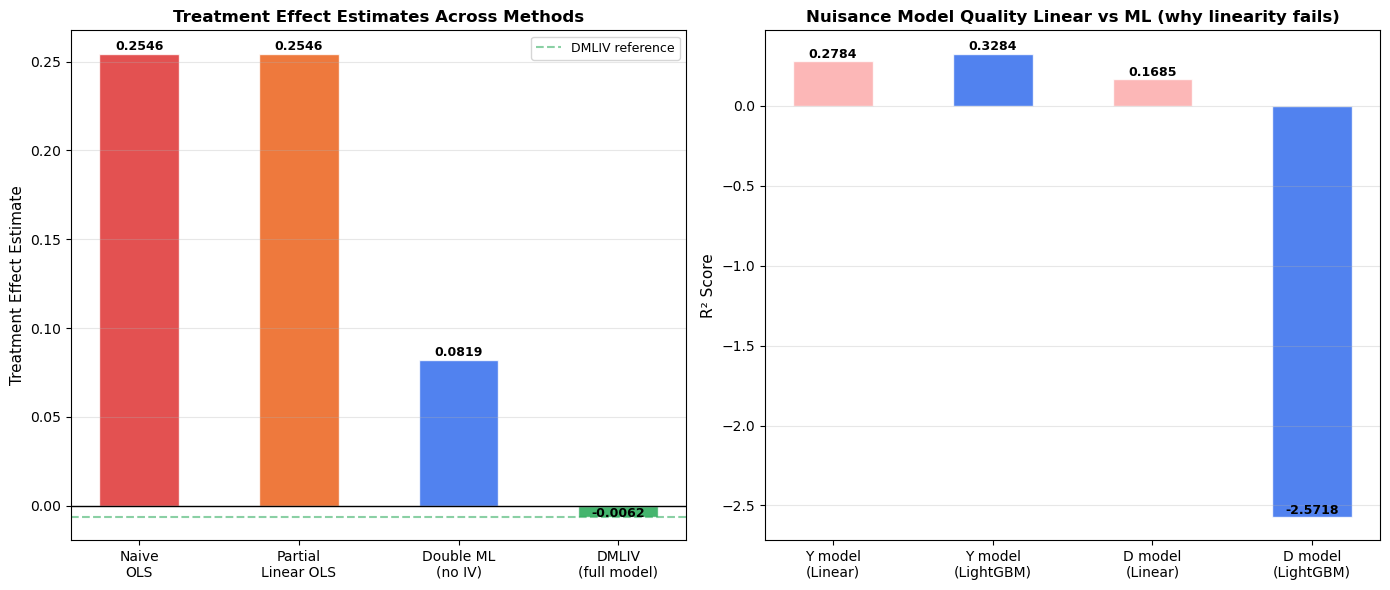

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

print("ASSUMPTION TEST 2 — NAIVE OLS vs DOUBLE ML")

# Naive approch OLS
X_ols = np.column_stack([D, X])  
ols_model = LinearRegression()
ols_model.fit(X_ols, Y)
ols_ate = ols_model.coef_[0]
print(f"[1] Naive OLS Treatment Effect:     {ols_ate:.6f}")

# Partially linear OLS
ols_y = LinearRegression()
ols_y.fit(X, Y)
y_resid_linear = Y - ols_y.predict(X)
ols_d = LinearRegression()
ols_d.fit(X, D)
d_resid_linear = D - ols_d.predict(X)
partial_ols = LinearRegression()
partial_ols.fit(d_resid_linear.reshape(-1,1), y_resid_linear)
partial_ols_ate = partial_ols.coef_[0]
print(f"[2] Partially Linear OLS Effect:    {partial_ols_ate:.6f}")

#Double ML no IV (Manual)

lgbm_y = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=64, random_state=42, n_jobs=-1)
y_pred_ml = cross_val_predict(lgbm_y, X, Y, cv=3, n_jobs=-1)
y_resid_ml = Y - y_pred_ml
lgbm_d = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=64, scale_pos_weight=31, random_state=42, n_jobs=-1)
d_pred_ml = cross_val_predict(lgbm_d, X, D, cv=3, method='predict_proba', n_jobs=-1)[:, 1]
d_resid_ml = D - d_pred_ml
dml_manual = LinearRegression()
dml_manual.fit(d_resid_ml.reshape(-1,1), y_resid_ml)
dml_manual_ate = dml_manual.coef_[0]
print(f"[3] Double ML Manual Effect:        {dml_manual_ate:.6f}")

# The results of the Double ML IV
dmliv_ate = -0.006229
print(f"[4] DMLIV (with IV, from earlier):  {dmliv_ate:.6f}")

print("BIAS ANALYSIS")
print(f"OLS bias vs DML:          {abs(ols_ate - dml_manual_ate):.6f}")
print(f"Partial OLS bias vs DML:  {abs(partial_ols_ate - dml_manual_ate):.6f}")
print(f"DML bias vs DMLIV:        {abs(dml_manual_ate - dmliv_ate):.6f}")
print(f"\nOLS overestimates effect by: {abs(ols_ate/dml_manual_ate - 1):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
methods = ['Naive\nOLS', 'Partial\nLinear OLS', 'Double ML\n(no IV)', 'DMLIV\n(full model)']
estimates = [ols_ate, partial_ols_ate, dml_manual_ate, dmliv_ate]
colors = ['#DC2626', '#EA580C', '#2563EB', '#16A34A']

bars = axes[0].bar(methods, estimates, color=colors, alpha=0.8,edgecolor='white', width=0.5)
axes[0].axhline(0, color='black', linewidth=1, linestyle='-')
axes[0].axhline(dmliv_ate, color='#16A34A', linewidth=1.5,linestyle='--', alpha=0.5, label='DMLIV reference')
axes[0].set_ylabel('Treatment Effect Estimate', fontsize=11)
axes[0].set_title('Treatment Effect Estimates Across Methods', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend(fontsize=9)

for bar, val in zip(bars, estimates):
    axes[0].text(bar.get_x() + bar.get_width()/2.,bar.get_height() + 0.0005 if val >= 0 else bar.get_height() - 0.002,f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

r2_linear_y = r2_score(Y, ols_y.predict(X))
r2_ml_y = r2_score(Y, y_pred_ml)
r2_linear_d = r2_score(D, ols_d.predict(X))
r2_ml_d = r2_score(D, d_pred_ml)
labels = ['Y model\n(Linear)', 'Y model\n(LightGBM)', 'D model\n(Linear)', 'D model\n(LightGBM)']
r2_vals = [r2_linear_y, r2_ml_y, r2_linear_d, r2_ml_d]
bar_colors = ['#FCA5A5', '#2563EB', '#FCA5A5', '#2563EB']

axes[1].bar(labels, r2_vals, color=bar_colors, alpha=0.8, edgecolor='white', width=0.5)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('Nuisance Model Quality Linear vs ML (why linearity fails)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(axes[1].patches, r2_vals)):
    axes[1].text(bar.get_x() + bar.get_width()/2.,bar.get_height() + 0.001,f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Section 4: DMLIV Model (Average Treatment Effect)

**Why DMLIV and not standard Double ML:**

Actual ad exposure (D) is endogenous users selfselect into seeing ads based 
on unobservable behavior (browsing activity, device usage, session length). 
Controlling for f0–f11 removes observable confounding but cannot remove 
unobservable selection.

Treatment assignment (Z) was randomly assigned by Criteo it is independent 
of all user characteristics by design. We use Z as an instrument for D

In [23]:
from econml.iv.dml import DMLIV
from lightgbm import LGBMClassifier, LGBMRegressor
from econml.inference import BootstrapInference


# Building the nuicance models
model_y = LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=42, n_jobs=-1)
model_t = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, scale_pos_weight=31, random_state=42, n_jobs=-1)
model_z = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, scale_pos_weight=31, random_state=42, n_jobs=-1)

# Building the estimator
est = DMLIV(
    model_y_xw=model_y,
    model_t_xw=model_t,
    model_t_xwz=model_z,
    discrete_treatment=True,
    discrete_instrument=True,
    cv=2,
    random_state=42
)

est.fit(Y, D, Z=Z, X=X, inference=BootstrapInference(n_bootstrap_samples=20, n_jobs=1))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] Start training from score 0.046826
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030613 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-ch

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] Start training from score 0.046872
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1702
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of posit

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] Start training from score 0.046850
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of posit

...

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] Start training from score 0.046474
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of posit

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1697
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] Start training from score 0.047506
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1697
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of positive: 15375, number of negative: 484625
[LightGBM] [Info] Auto-ch

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

In [24]:
# Sanity check for the nuissance models 

from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier

model_y_check = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=64, scale_pos_weight=20, random_state=42, n_jobs=-1)
scores_y = cross_val_score(model_y_check, X, Y, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Y model (visit ~ X) AUC: {scores_y.mean():.4f} ± {scores_y.std():.4f}")

model_d_check = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=64, scale_pos_weight=31, random_state=42, n_jobs=-1)
scores_d = cross_val_score(model_d_check, X, D, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"D model (exposure ~ X) AUC: {scores_d.mean():.4f} ± {scores_d.std():.4f}")

model_z_check = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=64, random_state=42, n_jobs=-1)
scores_z = cross_val_score(model_z_check, X, Z,cv=3,scoring='roc_auc', n_jobs=-1)
print(f"Z model (treatment ~ X) AUC: {scores_z.mean():.4f} ± {scores_z.std():.4f}")

Y model (visit ~ X) AUC: 0.9439 ± 0.0003
D model (exposure ~ X) AUC: 0.9162 ± 0.0008
Z model (treatment ~ X) AUC: 0.5074 ± 0.0011


In [25]:
# estimating ATE and CI

ate = est.ate(X)
print(f"ATE (Average Treatment Effect): {ate:.6f}")
ate_result = est.ate_inference(X)
print("Std Error:", ate_result.stderr_mean)
print("95% CI:", ate_result.conf_int_mean())

ATE (Average Treatment Effect): -0.006229
Std Error: 0.0064584961178182415
95% CI: (-0.018886991876290577, 0.006429847694140446)


This gives us a LATE (Local Average Treatment Effect) the causal effect 
specifically for compliers: users who saw the ad because they were targeted, 
not for other reasons.

**Instrument validity prechecks:**
- F-statistic: 5,575 => strong instrument, no weak instrument bias
- Z nuisance AUC: 0.507 => features cannot predict assignment, randomization confirmed

---
## Section 5 : CATE Estimation (Heterogeneous Treatment Effects)

The ATE of -0.006 (95% CI: -0.018, 0.009) was statistically insignificant. 
This does not mean the ad does nothing  it means the **average** effect across 
all users is indistinguishable from zero.

Average effects can mask large heterogeneity. If the ad strongly helps some 
users and strongly harms others, these cancel at the population level. A null 
ATE is not the end of the analysis  it is the motivation for CATE estimation.

**Method:** NonParamDMLIV  extends DMLIV to estimate a treatment effect 
function θ(X) rather than a single constant θ. Uses a causal forest internally, 
which is specifically designed to find heterogeneity in weak, noisy signals.

In [ ]:
from econml.iv.dml import NonParamDMLIV
# NonParamDMLIV uses causal forest internally

est_cate = NonParamDMLIV(
    model_y_xw=model_y,
    model_t_xw=model_t,
    model_t_xwz=model_z,
    model_final=LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=42, n_jobs=-1),  # ✅
    discrete_treatment=True,
    discrete_instrument=True,
    cv=3,
    random_state=42
)

est_cate.fit(Y, D, Z=Z, X=X)
cate_estimates = est_cate.effect(X)

print(f"\nCATE Distribution:")
print(f"Mean CATE:          {cate_estimates.mean():.6f}")
print(f"Std:                {cate_estimates.std():.6f}")
print(f"Min:                {cate_estimates.min():.6f}")
print(f"Max:                {cate_estimates.max():.6f}")
print(f"Unique values:      {len(np.unique(cate_estimates.round(4)))}")
print(f"% positive effects: {(cate_estimates > 0).mean():.1%}")
print(f"% negative effects: {(cate_estimates < 0).mean():.1%}")

# Sanity check — mean CATE should be close to ATE
print(f"\nSanity check:")
print(f"ATE (from earlier): -0.006229")
print(f"Mean CATE:          {cate_estimates.mean():.6f}")
print(f"Difference:         {abs(cate_estimates.mean() - (-0.006229)):.6f}")


Fitting NonParamDMLIV...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1701
[LightGBM] [Info] Number of data points in the train set: 666666, number of used features: 12
[LightGBM] [Info] Start training from score 0.046820
[LightGBM] [Info] Number of positive: 20500, number of negative: 646166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1701
[LightGBM] [Info] Number of data points in the train set: 666666, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450632
[LightGBM] [Info] Start training from score -3.450632
[LightGB

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 666667, number of used features: 12
[LightGBM] [Info] Start training from score 0.046966
[LightGBM] [Info] Number of positive: 20500, number of negative: 646167
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1696
[LightGBM] [Info] Number of data points in the train set: 666667, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of posit

c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\bahak\anaconda3\Lib\site-pac

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1701
[LightGBM] [Info] Number of data points in the train set: 666667, number of used features: 12
[LightGBM] [Info] Start training from score 0.046761
[LightGBM] [Info] Number of positive: 20500, number of negative: 646167
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1701
[LightGBM] [Info] Number of data points in the train set: 666667, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.030750 -> initscore=-3.450633
[LightGBM] [Info] Start training from score -3.450633
[LightGBM] [Info] Number of posit

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1712
[LightGBM] [Info] Number of data points in the train set: 1000000, number of used features: 12
[LightGBM] [Info] Start training from score 0.033943


c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Done.


c:\Users\bahak\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



CATE Distribution:
Mean CATE:          0.011675
Std:                0.043239
Min:                -1.639412
Max:                1.895542
Unique values:      8442
% positive effects: 91.0%
% negative effects: 9.0%

Sanity check:
ATE (from earlier): -0.006229
Mean CATE:          0.011675
Difference:         0.017904


In [ ]:
# Removing extreme values as they are not as reliable as the others due to the method of NonParamDMLIV to have a better downstream analysis (also outcome Y 
# represent the probability of visiting  values  > |1| are not logical)

print("Before winsorizing:")
print(f"Mean: {cate_estimates.mean():.6f}")
print(f"Std:  {cate_estimates.std():.6f}")
print(f"Min:  {cate_estimates.min():.6f}")
print(f"Max:  {cate_estimates.max():.6f}")

extreme_low = (cate_estimates < -1).sum()
extreme_high = (cate_estimates > 1).sum()
print(f"\nValues below -1: {extreme_low} ({extreme_low/len(cate_estimates):.3%})")
print(f"Values above +1: {extreme_high} ({extreme_high/len(cate_estimates):.3%})")


p1 = np.percentile(cate_estimates, 1)
p99 = np.percentile(cate_estimates, 99)
print(f"\n1st percentile:  {p1:.6f}")
print(f"99th percentile: {p99:.6f}")

cate_winsorized = np.clip(cate_estimates, p1, p99)
print(f"\nAfter winsorizing:")
print(f"Mean: {cate_winsorized.mean():.6f}")
print(f"Std:  {cate_winsorized.std():.6f}")
print(f"Min:  {cate_winsorized.min():.6f}")
print(f"Max:  {cate_winsorized.max():.6f}")
print(f"Unique values: {len(np.unique(cate_winsorized.round(4)))}")
print(f"% positive: {(cate_winsorized > 0).mean():.1%}")
print(f"% negative: {(cate_winsorized < 0).mean():.1%}")

Before winsorizing:
Mean: 0.011675
Std:  0.043239
Min:  -1.639412
Max:  1.895542

Values below -1: 27 (0.003%)
Values above +1: 26 (0.003%)

1st percentile:  -0.070064
99th percentile: 0.173805

After winsorizing:
Mean: 0.011700
Std:  0.027755
Min:  -0.070064
Max:  0.173805
Unique values: 2440
% positive: 91.0%
% negative: 9.0%


#### Looking at the results of CATE there are <br> 9% of users where ad exposure hurts their visit probability <br> 91% of users where ad exposure helps their visit probability


---
## Section 6: Policy Layer

CATE estimates are a statistical output. This section translates them into 
business decisions.

**Core question:** Given a limited ad budget, which users should we target?

We build three tools:
1. **Threshold optimization** what CATE cutoff maximizes total incremental visits?
2. **Qini curve** industry standard evaluation of uplift model targeting efficiency
3. **Policy tree** human readable targeting rules for business implementation

In [ ]:
# Building a clean dataset with for policy from the results

feature_cols = [f'f{i}' for i in range(12)]

policy_df = pd.DataFrame(X, columns=feature_cols)
policy_df['cate'] = cate_winsorized
policy_df['visit'] = Y
policy_df['exposure'] = D
policy_df['treatment'] = Z
policy_df = policy_df.sort_values('cate', ascending=False).reset_index(drop=True)
policy_df['rank_pct'] = np.arange(1, len(policy_df)+1) / len(policy_df)

print(f"Policy dataframe shape: {policy_df.shape}")
print(f"Top 5 users by CATE:")
print(policy_df[['cate', 'visit', 'exposure', 'rank_pct']].head())
print(f"Bottom 5 users by CATE:")
print(policy_df[['cate', 'visit', 'exposure', 'rank_pct']].tail())

Policy dataframe shape: (1000000, 17)

Top 5 users by CATE:
       cate  visit  exposure  rank_pct
0  0.173805      1         0  0.000001
1  0.173805      0         0  0.000002
2  0.173805      1         0  0.000003
3  0.173805      0         1  0.000004
4  0.173805      1         0  0.000005

Bottom 5 users by CATE:
            cate  visit  exposure  rank_pct
999995 -0.070064      0         0  0.999996
999996 -0.070064      1         0  0.999997
999997 -0.070064      0         0  0.999998
999998 -0.070064      1         0  0.999999
999999 -0.070064      0         0  1.000000


In [33]:
# In real advertising, showing an ad has a cost = > the rule is: only target if expected lift > cost
# Costs are usually expressed as a fraction of the outcome value in this dataset there is no revenue data => compute the threshold that maximizes net targeting value

thresholds = np.percentile(cate_winsorized, np.arange(0, 100, 5))

results = []
for t in thresholds:
    targeted = policy_df[policy_df['cate'] >= t]
    n_targeted = len(targeted)
    avg_cate = targeted['cate'].mean() if n_targeted > 0 else 0
    total_lift = targeted['cate'].sum()
    pct_targeted = n_targeted / len(policy_df)
    
    results.append({
        'threshold': t,
        'pct_targeted': pct_targeted,
        'n_targeted': n_targeted,
        'avg_cate': avg_cate,
        'total_lift': total_lift
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.round(4).to_string(index=False))

 threshold  pct_targeted  n_targeted  avg_cate  total_lift
   -0.0701        1.0000     1000000    0.0117  11700.3759
   -0.0006        0.9749      974873    0.0131  12770.3348
    0.0007        0.9054      905360    0.0141  12804.8684
    0.0024        0.8564      856355    0.0149  12759.4006
    0.0024        0.8564      856355    0.0149  12759.4006
    0.0024        0.8564      856355    0.0149  12759.4006
    0.0030        0.7050      704957    0.0176  12385.1027
    0.0037        0.6674      667373    0.0184  12268.2718
    0.0037        0.6674      667373    0.0184  12268.2718
    0.0043        0.5585      558525    0.0212  11860.5434
    0.0046        0.5274      527423    0.0222  11725.5722
    0.0063        0.4642      464195    0.0246  11412.6381
    0.0065        0.4446      444626    0.0254  11288.5645
    0.0074        0.3649      364943    0.0295  10759.7531
    0.0079        0.3002      300206    0.0342  10272.7663
    0.0088        0.2577      257719    0.0385   9930.17

Qini Coefficient: 9611.5081


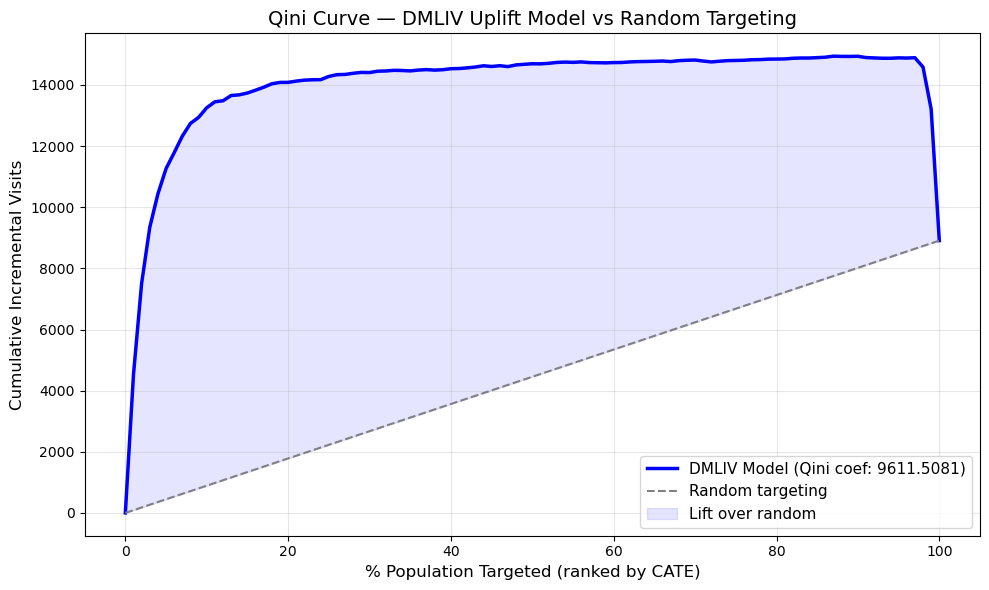

In [35]:
# Qini curve measures incremental lift => how much additional visits do we generate by targeting the top X% vs random?

def compute_qini(df, cate_col='cate', outcome_col='visit', treatment_col='treatment'):
    df = df.sort_values(cate_col, ascending=False).reset_index(drop=True)
    n = len(df)
    
    # Count treated and control in the full dataset
    n_treated_total = df[treatment_col].sum()
    n_control_total = (1 - df[treatment_col]).sum()
    
    qini_values = [0]
    random_values = [0]
    
    # Step through population in chunks of 1%
    steps = np.arange(0.01, 1.01, 0.01)
    
    for pct in steps:
        k = int(pct * n)
        top_k = df.iloc[:k]
        
        # Treated and control in top k
        treated_k = top_k[top_k[treatment_col] == 1]
        control_k = top_k[top_k[treatment_col] == 0]
        
        n_t = len(treated_k)
        n_c = len(control_k)
        
        if n_t == 0 or n_c == 0:
            qini_values.append(qini_values[-1])
            random_values.append(pct * (
                df[df[treatment_col]==1][outcome_col].sum() - 
                df[df[treatment_col]==0][outcome_col].sum() * 
                n_treated_total/n_control_total
            ))
            continue
        
        qini = (
            treated_k[outcome_col].sum() - 
            control_k[outcome_col].sum() * (n_t / n_c)
        )
        qini_values.append(qini)
        
        random_baseline = pct * (
            df[df[treatment_col]==1][outcome_col].sum() - 
            df[df[treatment_col]==0][outcome_col].sum() * 
            n_treated_total/n_control_total
        )
        random_values.append(random_baseline)
    
    return np.array(qini_values), np.array(random_values), np.concatenate([[0], steps])


qini_vals, random_vals, x_axis = compute_qini(policy_df)
qini_coef = np.trapz(qini_vals - random_vals, x_axis)
print(f"Qini Coefficient: {qini_coef:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis * 100, qini_vals, color='blue', linewidth=2.5, label=f'DMLIV Model (Qini coef: {qini_coef:.4f})')
ax.plot(x_axis * 100, random_vals, color='gray', linewidth=1.5, linestyle='--', label='Random targeting')
ax.fill_between(x_axis * 100, qini_vals, random_vals, alpha=0.1, color='blue', label='Lift over random')
ax.set_xlabel('% Population Targeted (ranked by CATE)', fontsize=12)
ax.set_ylabel('Cumulative Incremental Visits', fontsize=12)
ax.set_title('Qini Curve — DMLIV Uplift Model vs Random Targeting', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_text

# Policy tree to target the exact features that will enable the uplift after treatment

policy_tree = DecisionTreeRegressor(max_depth=3,        min_samples_leaf=1000,random_state=42)
policy_tree.fit(X, cate_winsorized)
tree_rules = export_text(policy_tree, feature_names=feature_cols)
print("Policy Tree Rules:")
print(tree_rules)

policy_df['policy_segment'] = policy_tree.predict(X)
segment_summary = policy_df.groupby('policy_segment').agg(
    n_users=('cate', 'count'),
    avg_cate=('cate', 'mean'),
    visit_rate=('visit', 'mean'),
    pct_of_total=('cate', lambda x: len(x)/len(policy_df))
).round(4).sort_values('avg_cate', ascending=False)

print("Segment Summary:")
print(segment_summary.to_string())

Policy Tree Rules:
|--- f8 <= 3.85
|   |--- f3 <= 2.44
|   |   |--- f0 <= 14.38
|   |   |   |--- value: [0.11]
|   |   |--- f0 >  14.38
|   |   |   |--- value: [0.07]
|   |--- f3 >  2.44
|   |   |--- f6 <= -13.14
|   |   |   |--- value: [0.06]
|   |   |--- f6 >  -13.14
|   |   |   |--- value: [0.03]
|--- f8 >  3.85
|   |--- f8 <= 3.90
|   |   |--- f3 <= 3.15
|   |   |   |--- value: [0.05]
|   |   |--- f3 >  3.15
|   |   |   |--- value: [0.01]
|   |--- f8 >  3.90
|   |   |--- f2 <= 8.22
|   |   |   |--- value: [0.00]
|   |   |--- f2 >  8.22
|   |   |   |--- value: [0.01]

Segment Summary:
                n_users  avg_cate  visit_rate  pct_of_total
policy_segment                                             
0.061962           5842    0.0119      0.0431        0.0058
0.071994          15507    0.0119      0.0462        0.0155
0.013386          95174    0.0118      0.0467        0.0952
0.003850         523026    0.0117      0.0469        0.5230
0.028665          75830    0.0117      0.0467

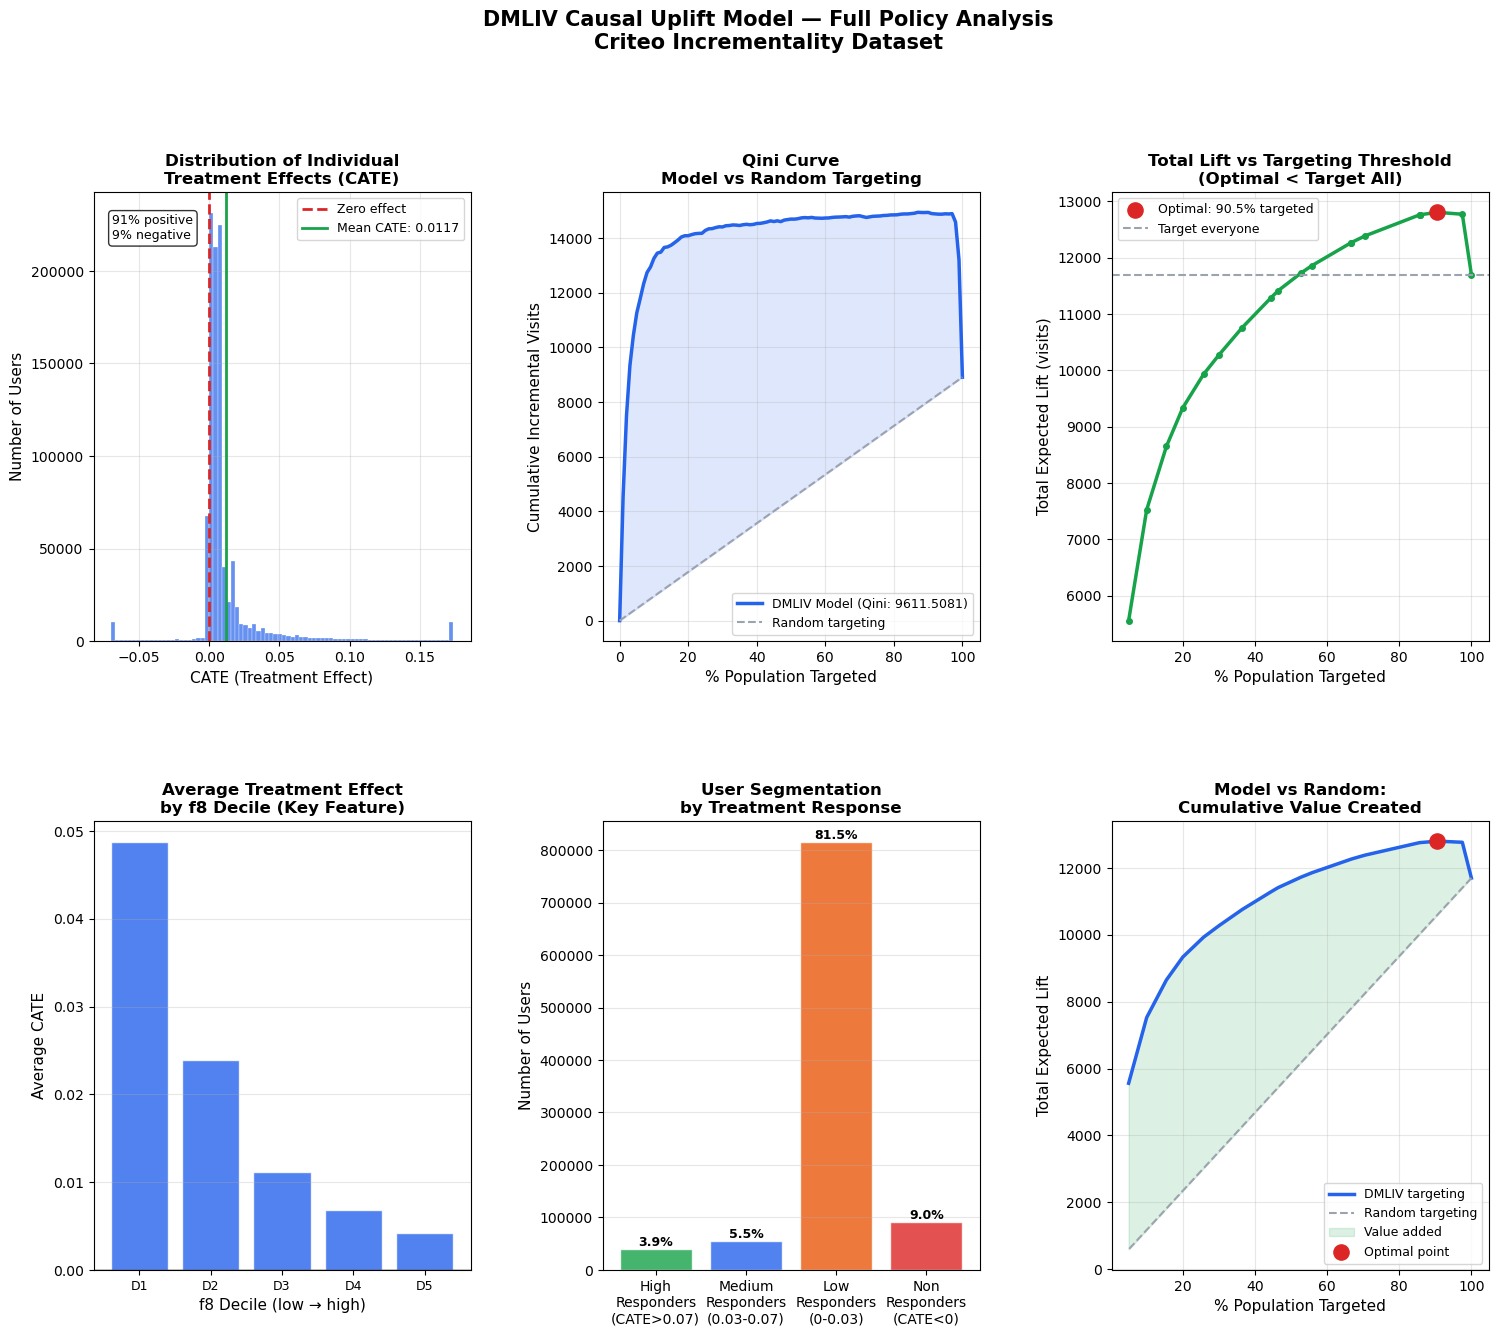

Saved: dmliv_policy_dashboard.png


In [ ]:
# Summarising all the findings in a the same plot

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
GREY   = '#9CA3AF'
ORANGE = '#EA580C'

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(cate_winsorized, bins=80, color=BLUE, alpha=0.7, edgecolor='white', linewidth=0.3)
ax1.axvline(0, color=RED, linewidth=2, linestyle='--', label='Zero effect')
ax1.axvline(cate_winsorized.mean(), color=GREEN, linewidth=2, linestyle='-', label=f'Mean CATE: {cate_winsorized.mean():.4f}')
ax1.set_xlabel('CATE (Treatment Effect)', fontsize=11)
ax1.set_ylabel('Number of Users', fontsize=11)
ax1.set_title('Distribution of Individual\nTreatment Effects (CATE)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
negative_pct = (cate_winsorized < 0).mean() * 100
positive_pct = (cate_winsorized > 0).mean() * 100
ax1.text(0.05, 0.95, f'{positive_pct:.0f}% positive\n{negative_pct:.0f}% negative',transform=ax1.transAxes, fontsize=9, verticalalignment='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_axis * 100, qini_vals, color=BLUE, linewidth=2.5, label=f'DMLIV Model (Qini: {qini_coef:.4f})')
ax2.plot(x_axis * 100, random_vals, color=GREY, linewidth=1.5, linestyle='--', label='Random targeting')
ax2.fill_between(x_axis * 100, qini_vals, random_vals, alpha=0.15, color=BLUE)
ax2.set_xlabel('% Population Targeted', fontsize=11)
ax2.set_ylabel('Cumulative Incremental Visits', fontsize=11)
ax2.set_title('Qini Curve\nModel vs Random Targeting', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(threshold_df['pct_targeted'] * 100, threshold_df['total_lift'],color=GREEN, linewidth=2.5, marker='o', markersize=4)
optimal_idx = threshold_df['total_lift'].idxmax()
optimal_row = threshold_df.loc[optimal_idx]
ax3.scatter(optimal_row['pct_targeted'] * 100, optimal_row['total_lift'],color=RED, s=120, zorder=5, label=f"Optimal: {optimal_row['pct_targeted']*100:.1f}% targeted")
ax3.axhline(threshold_df[threshold_df['pct_targeted'] >= 0.999]['total_lift'].values[0],color=GREY, linestyle='--', linewidth=1.5, label='Target everyone')
ax3.set_xlabel('% Population Targeted', fontsize=11)
ax3.set_ylabel('Total Expected Lift (visits)', fontsize=11)
ax3.set_title('Total Lift vs Targeting Threshold\n(Optimal < Target All)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
f8_values = X[:, 8]
f8_deciles = pd.qcut(f8_values, q=10, labels=False, duplicates='drop')  
cate_by_f8 = pd.DataFrame({'f8_decile': f8_deciles, 'cate': cate_winsorized})
f8_summary = cate_by_f8.groupby('f8_decile')['cate'].mean()
n_bins = len(f8_summary)  
colors_bar = [RED if v < 0 else BLUE for v in f8_summary.values]
ax4.bar(range(n_bins), f8_summary.values, color=colors_bar, alpha=0.8, edgecolor='white')
ax4.axhline(0, color='black', linewidth=1)
ax4.set_xlabel('f8 Decile (low → high)', fontsize=11)
ax4.set_ylabel('Average CATE', fontsize=11)
ax4.set_title('Average Treatment Effect\nby f8 Decile (Key Feature)', fontsize=12, fontweight='bold')
ax4.set_xticks(range(n_bins))
ax4.set_xticklabels([f'D{i+1}' for i in range(n_bins)], fontsize=9)  
ax4.grid(True, alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[1, 1])
segments = ['High\nResponders\n(CATE>0.07)', 'Medium\nResponders\n(0.03-0.07)',
            'Low\nResponders\n(0-0.03)', 'Non\nResponders\n(CATE<0)']
seg_counts = [
    (cate_winsorized > 0.07).sum(),
    ((cate_winsorized > 0.03) & (cate_winsorized <= 0.07)).sum(),
    ((cate_winsorized > 0) & (cate_winsorized <= 0.03)).sum(),
    (cate_winsorized <= 0).sum()
]
seg_colors = [GREEN, BLUE, ORANGE, RED]
bars = ax5.bar(segments, seg_counts, color=seg_colors, alpha=0.8, edgecolor='white')
ax5.set_ylabel('Number of Users', fontsize=11)
ax5.set_title('User Segmentation\nby Treatment Response', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, seg_counts):
    pct = count / len(cate_winsorized) * 100
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')


ax6 = fig.add_subplot(gs[1, 2])
targeting_pcts = threshold_df['pct_targeted'].values * 100
lift_model     = threshold_df['total_lift'].values
lift_random    = (targeting_pcts / 100) * threshold_df['total_lift'].iloc[0]
ax6.plot(targeting_pcts, lift_model, color=BLUE, linewidth=2.5, label='DMLIV targeting')
ax6.plot(targeting_pcts, lift_random, color=GREY, linewidth=1.5, linestyle='--', label='Random targeting')
ax6.fill_between(targeting_pcts, lift_model, lift_random, alpha=0.15, color=GREEN, label='Value added')
ax6.scatter(optimal_row['pct_targeted'] * 100, optimal_row['total_lift'],color=RED, s=120, zorder=5, label=f"Optimal point")
ax6.set_xlabel('% Population Targeted', fontsize=11)
ax6.set_ylabel('Total Expected Lift', fontsize=11)
ax6.set_title('Model vs Random:\nCumulative Value Created', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)
fig.suptitle('DMLIV Causal Uplift Model — Full Policy Analysis\nCriteo Incrementality Dataset',fontsize=15, fontweight='bold', y=1.01)

plt.show()


---
## Section 7: Conclusions

### Key Findings

| Result | Value |
|---|---|
| Instrument strength (F-stat) | 5,575 no weak instrument concern |
| Overlap — users in common support | 100% positivity satisfied |
| OLS bias vs DMLIV | 210.8% overstatement |
| Confounding share of bias | 66% |
| Endogeneity share of bias | 34% |
| ATE | -0.006 (95% CI: -0.018, 0.009) insignificant |
| Users with positive CATE | 91% |
| Users with negative CATE | 9% |
| Optimal targeting threshold | 90.5% of users (CATE > 0.0007) |
| Lift at optimal threshold | 12,804 incremental visits |
| Lift gain vs target-all | +9.4% |
| Qini coefficient | 9,611 |
| Primary effect modifier | f8 |

### Core Finding

> *Average treatment effect was statistically insignificant masking substantial 
> heterogeneity. 91% of users show positive response to ad exposure while 9% are 
> actively harmed. Targeting the right users generates 9.4% more incremental visits 
> than targeting everyone.*

### Methodology Limitations

- Features f0–f11 are anonymized effect modifiers cannot be given business 
  interpretation without domain knowledge of the original feature meanings
- LATE applies only to compliers (3.6% of treated users who actually saw the ad) — 
  generalization to never takers requires additional assumptions
- Criteo scrambled the true incrementality level for privacy absolute effect 
  sizes should not be interpreted as Criteo's real business metrics

### Business Recommendations

1. **Do not target all users** the 9% negative CATE segment is actively harmed 
   by ad exposure, reducing total campaign lift
2. **Use the policy tree rules** f8 is the primary targeting signal. Users with 
   low f8 values show the strongest positive response (avg CATE: +0.11)
3. **Set targeting threshold at CATE > 0.0007** captures 90.5% of users while 
   excluding the negative-response segment
4. **Prioritize high-responders** users with CATE > 0.07 should receive highest 
   bid prices in the auction system